# Import Packages

We'll make use of the following packages:
- `numpy` is a package for scientific computing in python.
- `pandas` A powerful Python library for data manipulation and analysis.
- `seaborn` A data visualization library based on matplotlib.
- `scikit-learn` A comprehensive library for machine learning in Python.
- `kaggle` Using Kaggle API to download data.

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import os
import math
import matplotlib.pyplot as plt
from scipy.stats import loguniform
import re
import string
from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

from sklearn.feature_extraction.text import CountVectorizer

# Download data

In [6]:
# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

In [7]:
print(os.listdir(path))

['Fake.csv', 'True.csv']


In [8]:
df_fake = pd.read_csv(os.path.join(path, 'Fake.csv'))
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [9]:
df_true = pd.read_csv(os.path.join(path, 'True.csv'))
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [10]:
df_true.info(), df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


(None, None)

> Both datasets include the columns `title`, `text`, `subject`, and `date`, all stored as object types. We will now perform EDA to generate insights by subject and date.

# Data Preprocessing

## Check missing values

In [11]:
## check missing values
df_fake.isna().sum(), df_true.isna().sum(),df_fake.isnull().sum(), df_true.isnull().sum()

(title      0
 text       0
 subject    0
 date       0
 dtype: int64,
 title      0
 text       0
 subject    0
 date       0
 dtype: int64,
 title      0
 text       0
 subject    0
 date       0
 dtype: int64,
 title      0
 text       0
 subject    0
 date       0
 dtype: int64)

> There is no null values in each column.

## Check Duplications

In [12]:
## check duplicates
df_fake.duplicated().sum(), df_true.duplicated().sum()

(3, 206)

In [13]:
df_fake[df_fake.duplicated(keep=False) == True]

,title,text,subject,date
9941,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017"
11445,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017"
14924,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"
14925,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015"


In [14]:
## Drop duplicates
df_fake.drop_duplicates(inplace=True)
df_true.drop_duplicates(inplace=True)
df_fake.duplicated().sum(), df_true.duplicated().sum()

(0, 0)

## Concat data

In [15]:
df_fake['true'] = 0
df_true['true'] = 1

df = pd.concat([df_true,df_fake], ignore_index=True)

In [16]:
df

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
44684,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44685,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44686,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44687,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


# Exploratory Data Analysis (EDA)

In [17]:
## bar and box plots for categorical features
def plot_bar_and_normalized_bars(dataframe, cat_cols, target_col, cols_per_row=2, figsize_per_plot=(6, 5), rotate_xticks=True):
    """
    For each categorical feature, plots a count bar chart on top and normalized stacked bar chart below.

    Parameters:
    - dataframe: pandas DataFrame
    - cat_cols: List of categorical columns
    - target_col: Column to group by (e.g., 'Attrition_Flag')
    - cols_per_row: Number of feature blocks per row (each block has 2 subplots)
    - figsize_per_plot: Tuple (width, height) per feature block
    - rotate_xticks: Rotate x-axis labels
    """
    n_features = len(cat_cols)
    n_cols = cols_per_row
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(nrows=n_rows * 2, ncols=n_cols,
                             figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows * 2))
    axes = axes.reshape((n_rows * 2, n_cols))

    for idx, col in enumerate(cat_cols):
        row_idx = (idx // n_cols) * 2
        col_idx = idx % n_cols

        # Top plot: Countplot (raw counts)
        sns.countplot(data=dataframe, x=col, hue=target_col,
                    ax=axes[row_idx][col_idx],
                    order=dataframe[col].value_counts().index)

        axes[row_idx][col_idx].set_title(f'{col} - Count by {target_col}')
        axes[row_idx][col_idx].set_xlabel('')
        axes[row_idx][col_idx].set_ylabel('Count')
        if rotate_xticks:
            axes[row_idx][col_idx].tick_params(axis='x', rotation=45)

        # Add count labels to each bar
        for container in axes[row_idx][col_idx].containers:
            for bar in container:
                height = bar.get_height()
                if height > 0:
                    axes[row_idx][col_idx].text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 0.01 * height,
                        f'{int(height)}',
                        ha='center', va='bottom', fontsize=8, color='black'
                    )

        # Bottom plot: Normalized bar chart
        norm_df = pd.crosstab(dataframe[col], dataframe[target_col], normalize='index')
        if 'Attrited Customer' in norm_df.columns:
            sorted_index = norm_df['Attrited Customer'].sort_values(ascending=False).index
        else:
            sorted_index = norm_df.iloc[:, 0].sort_values(ascending=False).index

        norm_df = norm_df.loc[sorted_index]
        norm_df.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[row_idx + 1][col_idx])
        axes[row_idx + 1][col_idx].set_title(f'{col} - Normalized % by {target_col}')
        axes[row_idx + 1][col_idx].set_ylabel('Proportion')
        axes[row_idx + 1][col_idx].set_xlabel(col)
        axes[row_idx + 1][col_idx].legend(title=target_col)

        if rotate_xticks:
            axes[row_idx + 1][col_idx].tick_params(axis='x', rotation=45)

        # Add % labels
        for idx2, category in enumerate(norm_df.index):
            bottom = 0
            for cls in norm_df.columns:
                height = norm_df.loc[category, cls]
                axes[row_idx + 1][col_idx].text(idx2, bottom + height / 2,
                                                f'{height*100:.1f}%', ha='center', va='center',
                                                fontsize=9, color='black')
                bottom += height

    # Hide any unused plots
    total_axes = n_rows * 2 * n_cols
    for i in range(idx + 1, total_axes // 2):
        axes[(i // n_cols) * 2][i % n_cols].set_visible(False)
        axes[(i // n_cols) * 2 + 1][i % n_cols].set_visible(False)

    plt.tight_layout()
    plt.show()

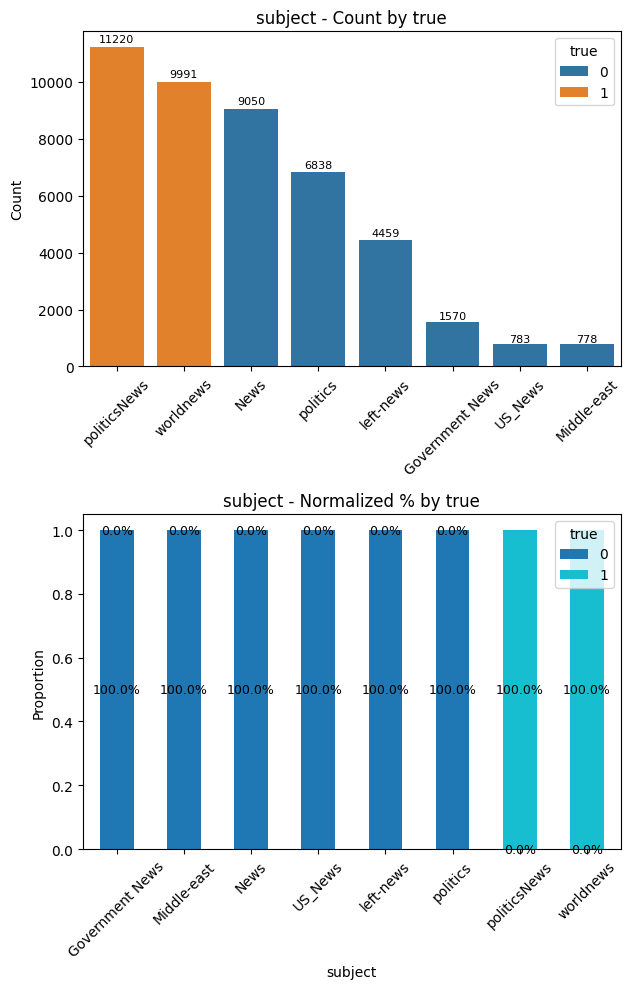

In [18]:
plot_bar_and_normalized_bars(df, ["subject"], "true", cols_per_row=2, figsize_per_plot=(6, 5), rotate_xticks=True)

> It appears the data source categorizes true and fake news differently by subject. All true news comes exclusively from `politicsNews` and `worldnews`, while fake news spans a wider range of categories, including `News`, `politics`, `left-news`, `Government News`, `US_News`, and `Middle-east`.
>
> 
> Therefore, subject category alone does not provide a reliable signal for distinguishing true from fake news in this dataset. We’ll proceed to text analysis for deeper insights.

# Text preprocessing

In [ ]:
## Clean Text
def clean_text(text, remove_stopwords=True, lemmatize=True):
    """
    Cleans the input text by removing special characters, numbers, and extra spaces.
    Converts the text to lowercase.
    
    Parameters:
    - text: str, input text to be cleaned
    - remove_stopwords: bool, whether to remove stopwords
    - lemmatize: bool, whether to lemmatize the words
    
    Returns:
    - str, cleaned text
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text
    tokens = text.split()

    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize the tokens
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

## Clean text

In [ ]:
## get cleaned text for both datasets
df_true['cleaned_text'] = df_true['text'].apply(clean_text)

df_fake['cleaned_text'] = df_fake['text'].apply(clean_text)

# Data Visualization
## Word Cloud

In [104]:
def plot_wordcloud(text_col, title, n = 1, top_n = 30, figsize=(12, 6)):
    """
    Plots a word cloud for the given text.
    
    Parameters:
    - text_col: DataFrame, input text for the word cloud
    - title: str, title for the plot
    - n: int, number of words to display in the word cloud
    - top_n: int, number of top n-grams to display
    - figsize: tuple, size of the figure
    """

    # Build n-grams
    n_grams = text_col.apply(lambda x: list(ngrams(x.split(), n)))

    # Flatten the list of n-grams
    flat_ngrams = ['_'.join(gram) for sub_set in n_grams for gram in sub_set]

    # select the top n words
    top_n_ngrams = dict(Counter(flat_ngrams).most_common(top_n))

    # Join all n-grams into a single string
    text = ' '.join(top_n_ngrams.keys())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    if n == 1:
        n_gram = 'Unigram'
    elif n == 2:
        n_gram = 'Bigram'
    elif n == 3:
        n_gram = 'Trigram'
    else:
        n_gram = f'{n}-gram'

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{n_gram} Word Cloud for {title}')
    plt.show()

    return top_n_ngrams

### Unigram

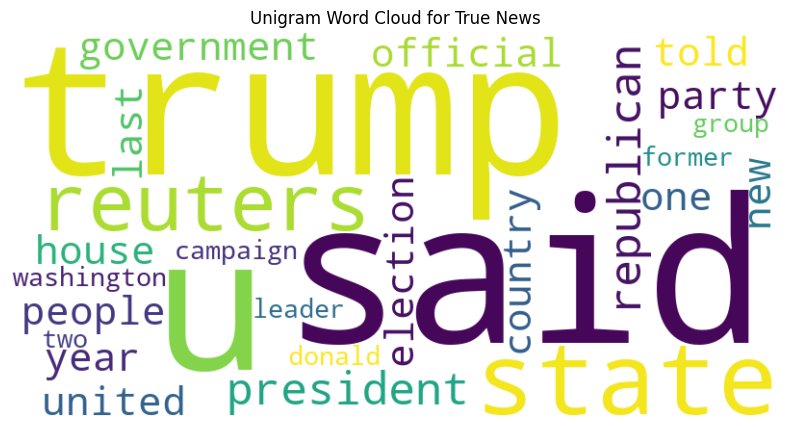

In [105]:
top_unigram_true = plot_wordcloud(df_true['cleaned_text'], 'True News')

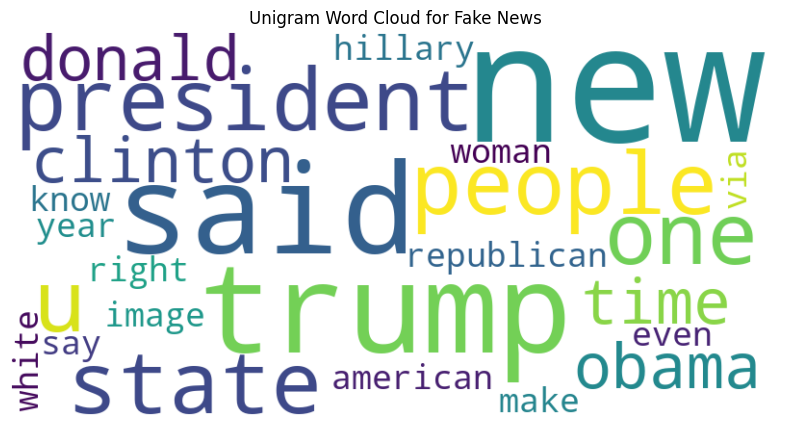

In [106]:
top_unigram_fake = plot_wordcloud(df_fake['cleaned_text'], 'Fake News')

### Bi-gram

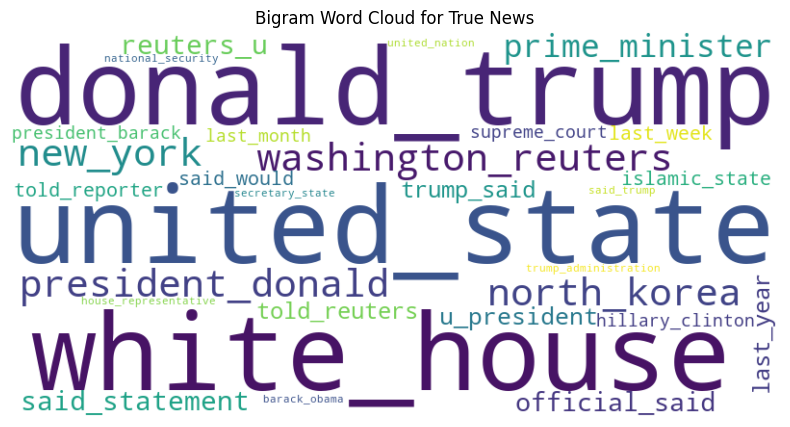

In [113]:
top_bigram_true = plot_wordcloud(df_true['cleaned_text'], 'True News', n = 2)

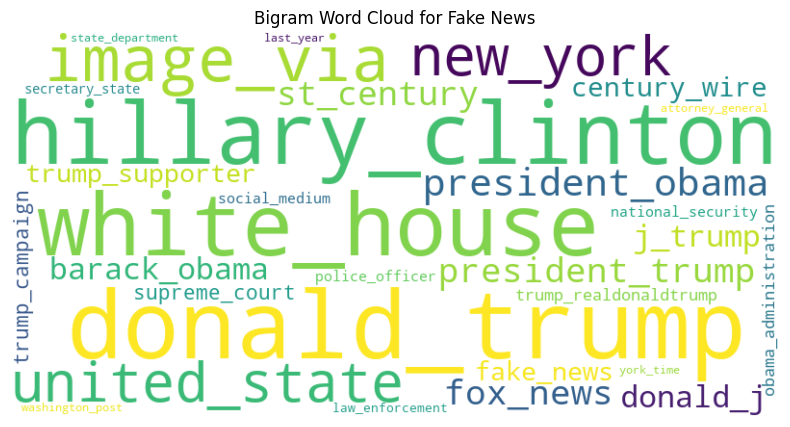

In [114]:
top_bigram_fake = plot_wordcloud(df_fake['cleaned_text'], 'Fake News', n= 2)

### Trip-gram

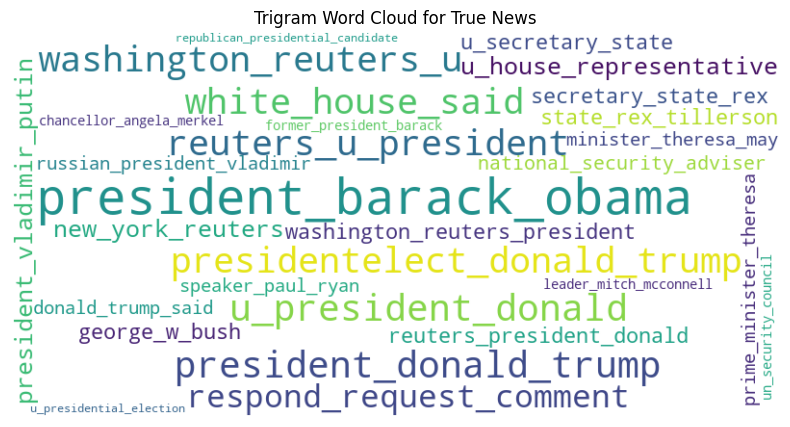

In [111]:
top_trigram_true = plot_wordcloud(df_true['cleaned_text'], 'True News', n = 3)

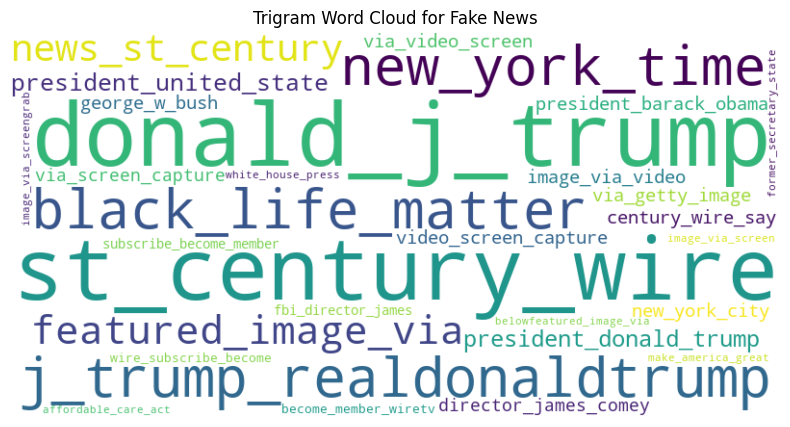

In [112]:
top_trigram_fake = plot_wordcloud(df_fake['cleaned_text'], 'Fake News', n=3)

- Analyzing unigrams—individual words—doesn’t provide much insight into the broader themes present in the dataset, as they’re often generic or too frequent to be meaningful. 

- When we move to bigram and trigram analysis, however, the dominant topics stand out far more clearly. Given that this dataset is centered around a presidential election, it’s not surprising to find that the most frequent bigrams and trigrams, in both true and fake news articles, revolve around presidential candidates and former presidents. This higher-order n-gram analysis gives us a richer understanding of how both classes of news frame the central players in the election.

- We’ll now switch to a bar plot to highlight the most commonly used terms.

## Bar Plot

In [128]:
def plot_rank_ngrams(count_dict, title, figsize= (12,6)):
    """
    Plots a bar chart of the n-grams ranked by their frequency.
    
    Parameters:
    - count_dict: dict, dictionary of n-grams and their counts
    - title: str, title for the plot
    - figsize: tuple, size of the figure
    """

    # sort the n-grams by their frequency
    sorted_ngrams = sorted(count_dict.items(), key= lambda x: x[1], reverse=True)

    # Extract n-grams and their counts
    ngrams, counts = zip(*sorted_ngrams)

    # Determine the n-gram type based on the number of underscores
    n = ngrams[0].count('_') + 1 
    
    if n == 1:
        n_gram = 'Unigram'
    elif n == 2:
        n_gram = 'Bigram'
    elif n == 3:
        n_gram = 'Trigram'
    else:
        n_gram = f'{n}-gram'
        
    # Plotting the bar chart
    plt.figure(figsize=figsize)
    sns.barplot(
        x=counts, 
        y=ngrams,
        hue=ngrams,
        palette='viridis'
        )
    plt.title(f'Ranked Top {n_gram} for {title}')

### Bigram

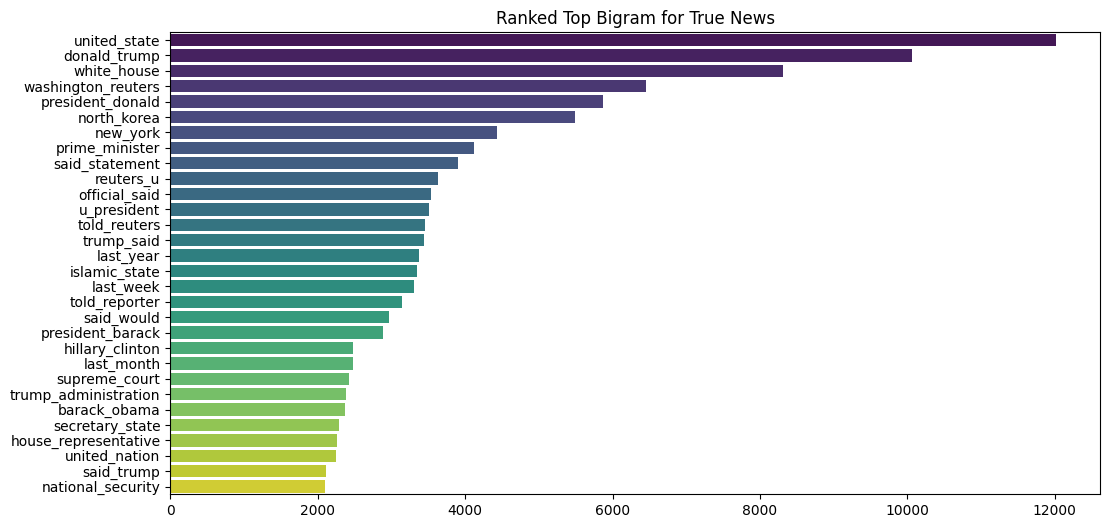

In [ ]:
plot_rank_ngrams(top_bigram_true, 'True News')

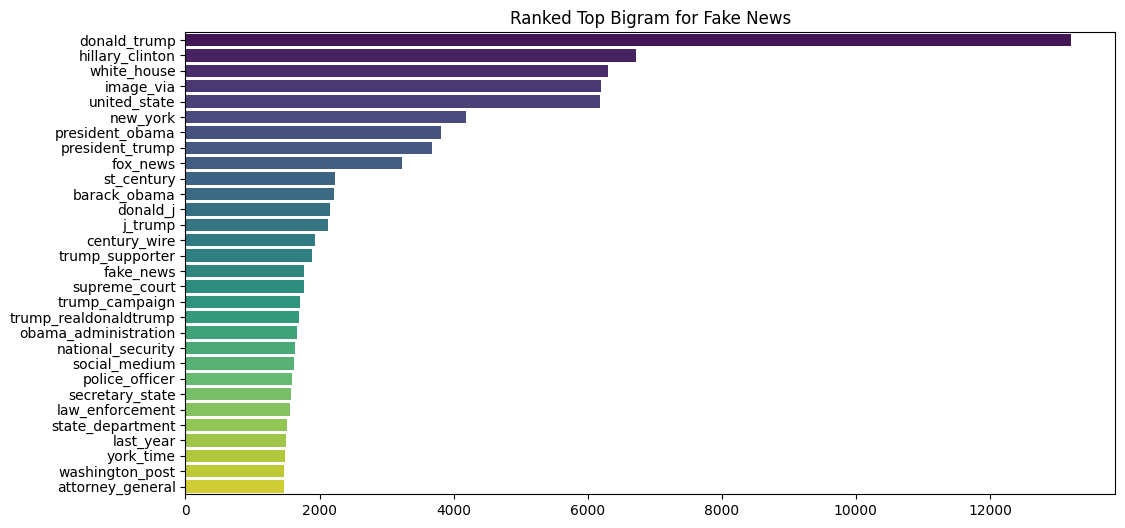

In [130]:
plot_rank_ngrams(top_bigram_fake, 'Fake News')

### Trigram

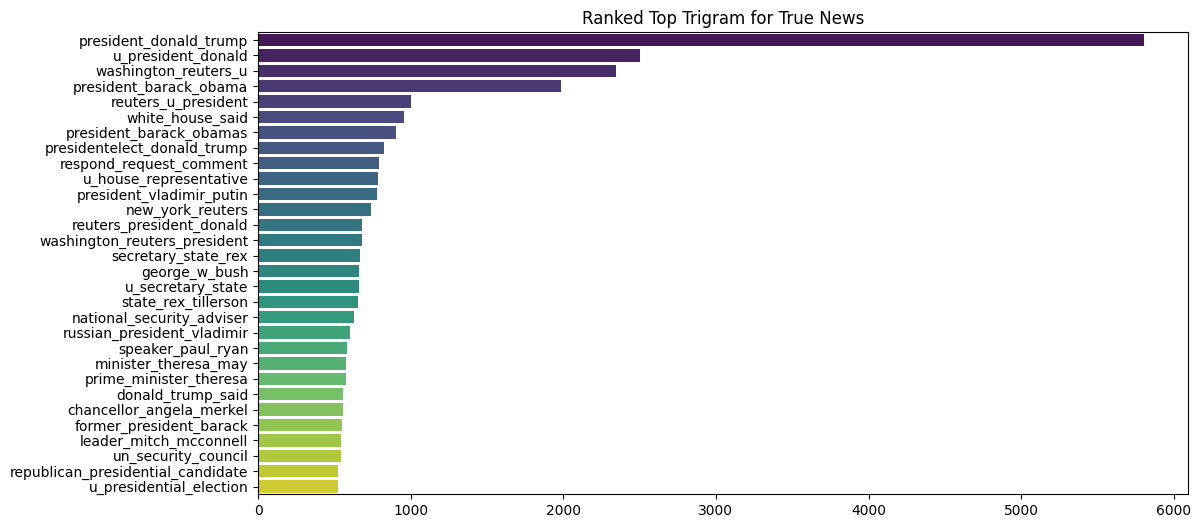

In [131]:
plot_rank_ngrams(top_trigram_true, 'True News')

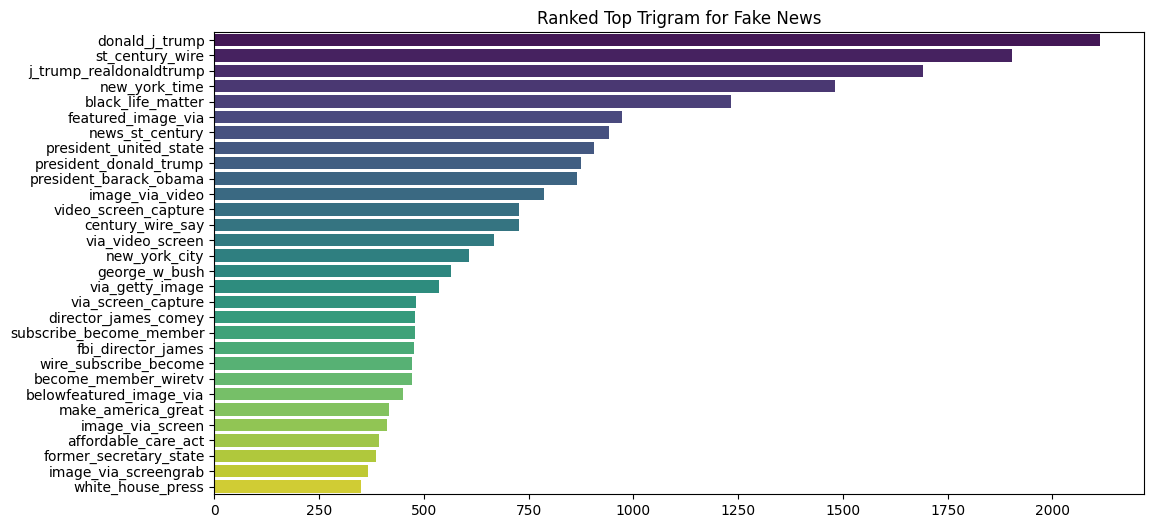

In [132]:
plot_rank_ngrams(top_trigram_fake, 'Fake News')

## N-gram Analysis: True vs. Fake News

The n-gram bar plots provide valuable insights into the linguistic patterns and topical focus of true versus fake news articles within this dataset.

### Bigram Analysis

Both true and fake news samples frequently reference prominent political figures and official terms—such as `donald_trump`, `hillary_clinton`, `white_house`, and `united_state`—reflecting the election-focused nature of the corpus. However, key differences emerge:

- **True news** bigrams are dominated by institutional and location-based phrases (e.g., `new_york`, `prime_minister`, `secretary_state`, `washington_reuters`). This formal, source-oriented language reflects the style of traditional journalism, emphasizing official titles and verified sources.
- **Fake news** bigrams, while also naming public figures, often include sensational or viral terms (e.g., `fake_news`, `image_via`, `century_wire`, `fox_news`). These n-grams suggest an attempt to mimic the authority of legitimate news while leveraging alternative outlets or viral content for engagement.

### Trigram Analysis

A similar pattern holds for trigrams:

- **True news** trigrams are characterized by formal attributions and repeated references to agencies, titles, and political leaders (e.g., `president_donald_trump`, `president_barack_obama`). This reflects the neutral, attribution-heavy reporting style of reputable sources.
- **Fake news** trigrams display more platform, campaign, or meme-like content (e.g., `donald_j_trump`, `st_century_wire`, `black_life_matter`, `featured_image_via`, `make_america_great`). These phrases highlight fake news’s tendency to focus on trending topics, social movements, and emotionally charged or viral language.

### Key Insights

- **Institutional vs. Viral Language:** True news articles are more likely to use institutional and formal language, while fake news leans toward viral and sensational terms.
- **Source Attribution:** Official titles and agencies are more common in true news, whereas fake news frequently cites alternative platforms or employs viral attributions.
- **Content Strategy:** Fake news often capitalizes on trending topics and social movements to maximize spread, while true news remains grounded in verified sources and conventional reporting style.

These findings demonstrate how n-gram analysis can reveal distinct linguistic signatures for true and fake news—offering both valuable insights for content strategy and practical features for downstream machine learning models.